# Prediccion del Tipo de Cambio USD/GEL con MLP

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)
device = 'cpu'
print('Dispositivo:', device)

Dispositivo: cpu


## Carga del Dataset

In [2]:
RUTA = r'C:\Users\Usuario\Desktop\INTELIG. ARTIF. 2\P1\DATASET\DatasetLARI\USD_GEL Historical Data.csv'

df = pd.read_csv(RUTA)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Rango: {df["Date"].iloc[0].date()}  a  {df["Date"].iloc[-1].date()}')
print(f'Filas: {len(df)}')
df.head()

Rango: 2001-05-11  a  2020-10-27
Filas: 4999


,Date,Price,Open,High,Low,Vol.,Change %
0,2001-05-11,2.0550,2.0550,2.0550,2.0550,NaN,0.24%
1,2001-05-14,2.0570,2.0570,2.0570,2.0570,NaN,0.10%
2,2001-05-15,2.0595,2.0595,2.0595,2.0595,NaN,0.12%
3,2001-05-16,2.0650,2.0650,2.0650,2.0650,NaN,0.27%
4,2001-05-17,2.0700,2.0700,2.0700,2.0700,NaN,0.24%


## Preprocesamiento

In [3]:
FEATURES   = ['Price', 'Open', 'High', 'Low']
ULTIMO_MES = 22
N_STEPS    = 14

df = df[['Date'] + FEATURES].dropna().reset_index(drop=True)

scaler     = MinMaxScaler()
datos_norm = scaler.fit_transform(df[FEATURES]).astype(np.float32)

datos_train_raw = datos_norm[:-ULTIMO_MES]
datos_test_raw  = datos_norm[-ULTIMO_MES:]
fechas_test     = df['Date'].iloc[-ULTIMO_MES:].values
precios_reales  = df['Price'].iloc[-ULTIMO_MES:].values

print(f'Train: {len(datos_train_raw)} dias')
print(f'Test : {len(datos_test_raw)} dias')

Train: 4977 dias
Test : 22 dias


## Ventanas Deslizantes

In [4]:
def build_windows(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i : i + n_steps])
        y.append(data[i + n_steps, [0]])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_all, y_all = build_windows(datos_train_raw, N_STEPS)

split_train      = int(len(X_all) * 0.8)
X_train, y_train = X_all[:split_train], y_all[:split_train]
X_valid, y_valid = X_all[split_train:], y_all[split_train:]

X_test_raw     = np.concatenate([datos_train_raw[-N_STEPS:], datos_test_raw], axis=0)
X_test, y_test = build_windows(X_test_raw, N_STEPS)

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_valid: {X_valid.shape} | y_valid: {y_valid.shape}')
print(f'X_test : {X_test.shape}  | y_test : {y_test.shape}')

X_train: (3970, 14, 4) | y_train: (3970, 1)
X_valid: (993, 14, 4) | y_valid: (993, 1)
X_test : (22, 14, 4)  | y_test : (22, 1)


## Dataset y DataLoader

In [5]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y=None, train=True):
        self.X     = X
        self.y     = y
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        if self.train:
            return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])
        return torch.from_numpy(self.X[ix])

dataset = {
    'train': TimeSeriesDataset(X_train, y_train),
    'eval' : TimeSeriesDataset(X_valid, y_valid),
    'test' : TimeSeriesDataset(X_test,  train=False)
}

dataloader = {
    'train': DataLoader(dataset['train'], shuffle=True,  batch_size=64),
    'eval' : DataLoader(dataset['eval'],  shuffle=False, batch_size=64),
    'test' : DataLoader(dataset['test'],  shuffle=False, batch_size=64)
}

## Modelo MLP

In [6]:
class MLP(torch.nn.Module):
    def __init__(self, n_in=56, n_out=1, dropout=0.1):
        super().__init__()
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(n_in, 32),
            torch.nn.ReLU(),
            torch.nn.Dropout(p=dropout),
            torch.nn.Linear(32, n_out)
        )

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        return self.fc(x)

mlp = MLP(n_in=N_STEPS * len(FEATURES))
mlp

MLP(
  (fc): Sequential(
    (0): Linear(in_features=56, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

## Entrenamiento con Early Stopping

In [7]:
EPOCHS    = 200
LR        = 5e-4
PATIENCE  = 15

optimizer = torch.optim.Adam(mlp.parameters(), lr=LR)
criterion = torch.nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=7
)

best_val_loss     = float('inf')
epochs_sin_mejora = 0
best_weights      = None
history           = {'train': [], 'val': []}

for epoch in tqdm(range(1, EPOCHS + 1), desc='Entrenando'):

    mlp.train()
    train_loss = 0.0
    for X_batch, y_batch in dataloader['train']:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(mlp(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(dataset['train'])

    mlp.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in dataloader['eval']:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            val_loss += criterion(mlp(X_batch), y_batch).item() * len(X_batch)
    val_loss /= len(dataset['eval'])

    history['train'].append(train_loss)
    history['val'].append(val_loss)
    scheduler.step(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        lr_actual = optimizer.param_groups[0]['lr']
        print(f'Epoca {epoch:>3} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {lr_actual:.6f}')

    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        best_weights      = {k: v.clone() for k, v in mlp.state_dict().items()}
        epochs_sin_mejora = 0
    else:
        epochs_sin_mejora += 1
        if epochs_sin_mejora >= PATIENCE:
            print(f'Early stopping en epoca {epoch} | Mejor Val Loss: {best_val_loss:.6f}')
            break

mlp.load_state_dict(best_weights)
print(f'Entrenamiento finalizado | Mejor Val Loss: {best_val_loss:.6f}')

Entrenando:   1%|          | 2/200 [00:00<00:13, 14.24it/s]

Epoca   1 | Train: 0.038169 | Val: 0.011184 | LR: 0.000500


Entrenando:   6%|▋         | 13/200 [00:00<00:09, 20.02it/s]

Epoca  10 | Train: 0.001219 | Val: 0.001320 | LR: 0.000500


Entrenando:  11%|█         | 22/200 [00:01<00:08, 20.67it/s]

...

Epoca  50 | Train: 0.000813 | Val: 0.000493 | LR: 0.000063


Entrenando:  30%|███       | 61/200 [00:02<00:06, 20.94it/s]

Epoca  60 | Train: 0.000773 | Val: 0.000426 | LR: 0.000031


Entrenando:  33%|███▎      | 66/200 [00:03<00:06, 20.16it/s]

Early stopping en epoca 67 | Mejor Val Loss: 0.000334
Entrenamiento finalizado | Mejor Val Loss: 0.000334


## Curva de Entrenamiento

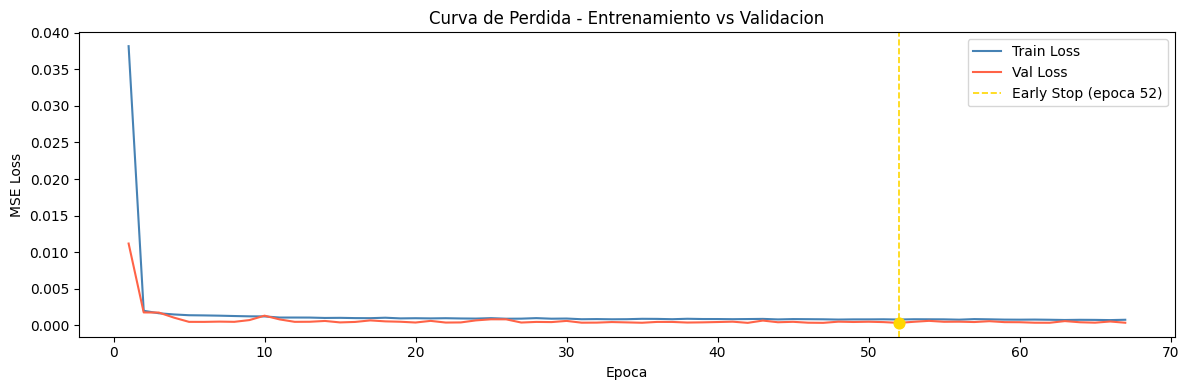

In [8]:
epochs_range = range(1, len(history['train']) + 1)
mejor_epoca  = history['val'].index(min(history['val'])) + 1
mejor_loss   = min(history['val'])

plt.figure(figsize=(12, 4))
plt.plot(epochs_range, history['train'], color='steelblue', linewidth=1.5, label='Train Loss')
plt.plot(epochs_range, history['val'],   color='tomato',    linewidth=1.5, label='Val Loss')
plt.axvline(x=mejor_epoca, color='gold', linestyle='--', linewidth=1.2, label=f'Early Stop (epoca {mejor_epoca})')
plt.scatter(mejor_epoca, mejor_loss, color='gold', zorder=5, s=60)
plt.title('Curva de Perdida - Entrenamiento vs Validacion')
plt.xlabel('Epoca')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Evaluacion sobre el Test Set

In [9]:
mlp.eval()
preds_norm = []

with torch.no_grad():
    for X_batch in dataloader['test']:
        preds_norm.append(mlp(X_batch.to(device)).cpu().numpy())

preds_norm = np.concatenate(preds_norm, axis=0)

dummy       = np.zeros((len(preds_norm), 4), dtype=np.float32)
dummy[:, 0] = preds_norm[:, 0]
preds_reales = scaler.inverse_transform(dummy)[:, 0]

mse  = mean_squared_error(precios_reales, preds_reales)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(precios_reales - preds_reales))
mape = np.mean(np.abs((precios_reales - preds_reales) / precios_reales)) * 100

print('Metricas sobre el Test Set (22 dias ocultos)')
print('-' * 40)
print(f'  MSE  : {mse:.6f}')
print(f'  RMSE : {rmse:.6f}')
print(f'  MAE  : {mae:.6f}')
print(f'  MAPE : {mape:.4f}%')

Metricas sobre el Test Set (22 dias ocultos)
----------------------------------------
  MSE  : 0.001526
  RMSE : 0.039063
  MAE  : 0.024425
  MAPE : 0.7549%


## Grafica: Prediccion vs Real (Test Set)

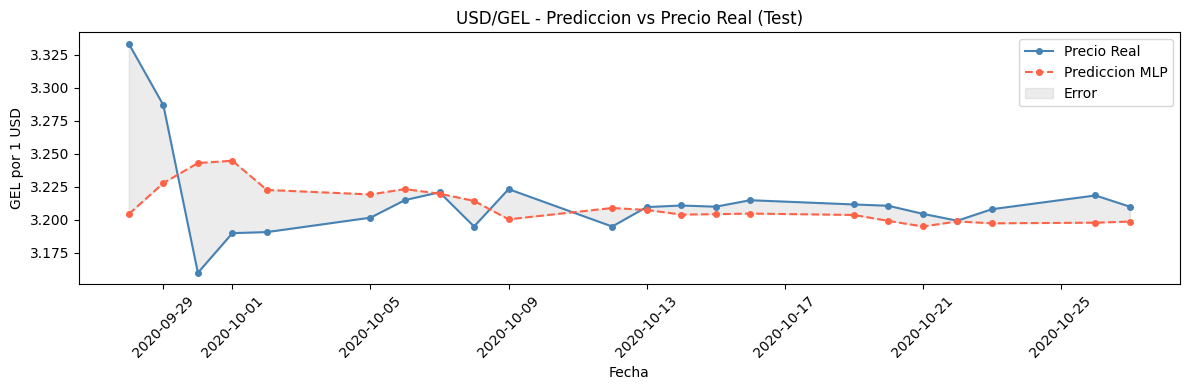

     Fecha   Real  Prediccion  Error Abs
2020-09-28 3.3332      3.2044     0.1288
2020-09-29 3.2868      3.2278     0.0590
2020-09-30 3.1600      3.2430     0.0830
2020-10-01 3.1900      3.2447     0.0547
2020-10-02 3.1908      3.2227     0.0319
2020-10-05 3.2017      3.2193     0.0176
2020-10-06 3.2150      3.2233     0.0083
2020-10-07 3.2209      3.2198     0.0011
2020-10-08 3.1950      3.2144     0.0194
2020-10-09 3.2233      3.2004     0.0229
2020-10-12 3.1950      3.2090     0.0140
2020-10-13 3.2097      3.2076     0.0021
2020-10-14 3.2109      3.2040     0.0069
2020-10-15 3.2100      3.2043     0.0057
2020-10-16 3.2149      3.2048     0.0101
2020-10-19 3.2117      3.2037     0.0080
2020-10-20 3.2107      3.1993     0.0114
2020-10-21 3.2046      3.1950     0.0096
2020-10-22 3.1994      3.1988     0.0006
2020-10-23 3.2081      3.1974     0.0107
2020-10-26 3.2185      3.1979     0.0206
2020-10-27 3.2100      3.1987     0.0113


In [10]:
plt.figure(figsize=(12, 4))
plt.plot(fechas_test, precios_reales, color='steelblue', linewidth=1.5, marker='o', markersize=4, label='Precio Real')
plt.plot(fechas_test, preds_reales,   color='tomato',    linewidth=1.5, marker='o', markersize=4, label='Prediccion MLP', linestyle='--')
plt.fill_between(fechas_test, precios_reales, preds_reales, alpha=0.15, color='gray', label='Error')
plt.title('USD/GEL - Prediccion vs Precio Real (Test)')
plt.xlabel('Fecha')
plt.ylabel('GEL por 1 USD')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

comparativa = pd.DataFrame({
    'Fecha'     : fechas_test,
    'Real'      : precios_reales.round(4),
    'Prediccion': preds_reales.round(4),
    'Error Abs' : np.abs(precios_reales - preds_reales).round(4)
})
print(comparativa.to_string(index=False))

## Prediccion de 30 Dias Futuros

In [11]:
DIAS_FUTURO = 30

ventana_actual = datos_norm[-N_STEPS:].copy()
predicciones_futuras = []

mlp.eval()
with torch.no_grad():
    for _ in range(DIAS_FUTURO):
        x_in  = torch.from_numpy(ventana_actual[np.newaxis]).to(device)
        pred  = mlp(x_in).cpu().numpy()[0, 0]
        predicciones_futuras.append(pred)

        nuevo_paso    = ventana_actual[-1].copy()
        nuevo_paso[0] = pred
        ventana_actual = np.vstack([ventana_actual[1:], nuevo_paso])

dummy_fut       = np.zeros((DIAS_FUTURO, 4), dtype=np.float32)
dummy_fut[:, 0] = predicciones_futuras
predicciones_futuras_reales = scaler.inverse_transform(dummy_fut)[:, 0]

ultima_fecha  = df['Date'].iloc[-1]
fechas_futuro = pd.date_range(start=ultima_fecha + pd.Timedelta(days=1), periods=DIAS_FUTURO, freq='B')

df_futuro = pd.DataFrame({
    'Fecha'     : fechas_futuro,
    'Prediccion': predicciones_futuras_reales.round(4)
})
print(df_futuro.to_string(index=False))

     Fecha  Prediccion
2020-10-28      3.1995
2020-10-29      3.2019
2020-10-30      3.1994
2020-11-02      3.1977
2020-11-03      3.1989
2020-11-04      3.2002
2020-11-05      3.1997
2020-11-06      3.2004
2020-11-09      3.1995
2020-11-10      3.1991
2020-11-11      3.1993
2020-11-12      3.1997
2020-11-13      3.2006
2020-11-16      3.2005
2020-11-17      3.1999
2020-11-18      3.2002
2020-11-19      3.1999
2020-11-20      3.1998
2020-11-23      3.1999
2020-11-24      3.2000
2020-11-25      3.1999
2020-11-26      3.2000
2020-11-27      3.2000
2020-11-30      3.1999
2020-12-01      3.1999
2020-12-02      3.1999
2020-12-03      3.1999
2020-12-04      3.1999
2020-12-07      3.1999
2020-12-08      3.1999


## Grafica: Predicciones Futuras

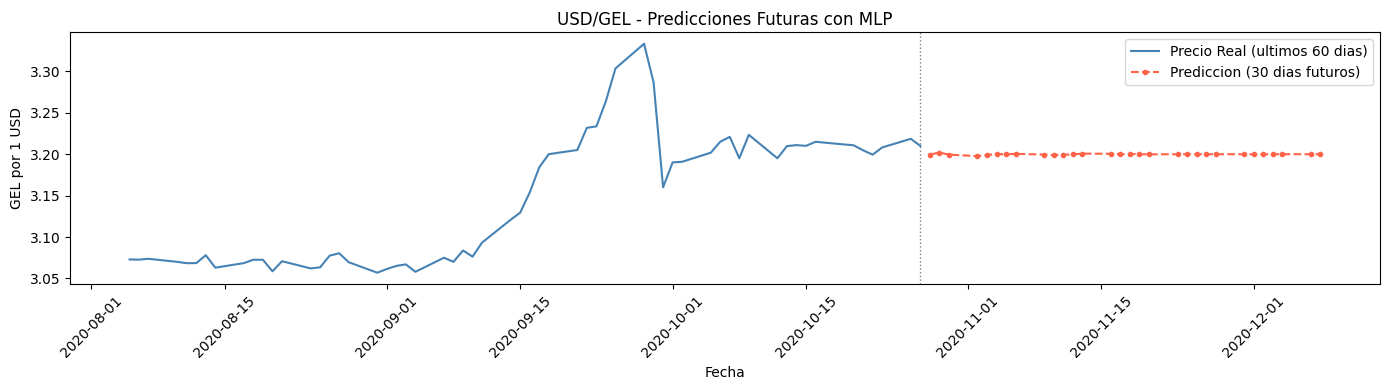

In [12]:
ultimos_reales = df['Price'].iloc[-60:].values
fechas_reales  = df['Date'].iloc[-60:].values

plt.figure(figsize=(14, 4))
plt.plot(fechas_reales,  ultimos_reales,               color='steelblue', linewidth=1.5, label='Precio Real (ultimos 60 dias)')
plt.plot(fechas_futuro,  predicciones_futuras_reales,  color='tomato',    linewidth=1.5, linestyle='--', marker='o', markersize=3, label=f'Prediccion ({DIAS_FUTURO} dias futuros)')
plt.axvline(x=ultima_fecha, color='gray', linestyle=':', linewidth=1)
plt.title('USD/GEL - Predicciones Futuras con MLP')
plt.xlabel('Fecha')
plt.ylabel('GEL por 1 USD')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 55)
print("       RESUMEN FINAL — MLP USD/GEL")
print("=" * 55)

print(f"\nDATASET")
print(f"  Rango            : {df['Date'].iloc[0].date()} a {df['Date'].iloc[-1].date()}")
print(f"  Total dias       : {len(df)}")
print(f"  Features         : {FEATURES}")

print(f"\nCONFIGURACION DEL MODELO")
print(f"  Ventana (n_steps): {N_STEPS} dias")
print(f"  Arquitectura     : Linear({N_STEPS*len(FEATURES)}->32) -> ReLU -> Dropout(0.1) -> Linear(32->1)")
print(f"  Optimizer        : Adam  |  LR inicial: {LR}")
print(f"  Early Stopping   : patience={PATIENCE}")

print(f"\nENTRENAMIENTO")
print(f"  Epocas ejecutadas: {len(history['train'])}")
print(f"  Mejor epoca      : {history['val'].index(min(history['val'])) + 1}")
print(f"  Mejor Val Loss   : {min(history['val']):.6f}")
print(f"  Train Loss final : {history['train'][-1]:.6f}")
print(f"  Val Loss final   : {history['val'][-1]:.6f}")

print(f"\nMETRICAS TEST SET ({ULTIMO_MES} dias ocultos)")
print(f"  MSE  : {mse:.6f}")
print(f"  RMSE : {rmse:.6f}")
print(f"  MAE  : {mae:.6f}")
print(f"  MAPE : {mape:.4f}%")

print(f"\nPREDICCIONES FUTURAS ({DIAS_FUTURO} dias habiles)")
print(f"  Desde : {fechas_futuro[0].date()}")
print(f"  Hasta : {fechas_futuro[-1].date()}")
print(f"  Min   : {predicciones_futuras_reales.min():.4f} GEL")
print(f"  Max   : {predicciones_futuras_reales.max():.4f} GEL")
print(f"  Media : {predicciones_futuras_reales.mean():.4f} GEL")
print(f"  Ultimo precio real conocido: {df['Price'].iloc[-1]:.4f} GEL")


       RESUMEN FINAL — MLP USD/GEL

DATASET
  Rango            : 2001-05-11 a 2020-10-27
  Total dias       : 4999
  Features         : ['Price', 'Open', 'High', 'Low']

CONFIGURACION DEL MODELO
  Ventana (n_steps): 14 dias
  Arquitectura     : Linear(56->32) -> ReLU -> Dropout(0.1) -> Linear(32->1)
  Optimizer        : Adam  |  LR inicial: 0.0005
  Early Stopping   : patience=15

ENTRENAMIENTO
  Epocas ejecutadas: 67
  Mejor epoca      : 52
  Mejor Val Loss   : 0.000334
  Train Loss final : 0.000761
  Val Loss final   : 0.000355

METRICAS TEST SET (22 dias ocultos)
  MSE  : 0.001526
  RMSE : 0.039063
  MAE  : 0.024425
  MAPE : 0.7549%

PREDICCIONES FUTURAS (30 dias habiles)
  Desde : 2020-10-28
  Hasta : 2020-12-08
  Min   : 3.1977 GEL
  Max   : 3.2019 GEL
  Media : 3.1998 GEL
  Ultimo precio real conocido: 3.2100 GEL

Copia este bloque y mandamelo para el veredicto final.
